# EDA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive

# 1. เชื่อมต่อ (Mount) Google Drive เข้ากับ Colab
# เมื่อรันบรรทัดนี้ จะมีหน้าต่างเด้งขึ้นมาให้คุณกดยืนยันสิทธิ์เข้าถึง Google Drive
drive.mount('/content/drive')

# 2. กำหนด Path ของไฟล์ที่อยู่ใน Google Drive
# หมายเหตุ: แก้ไขที่อยู่ไฟล์ตรงนี้ให้ตรงกับโฟลเดอร์ที่คุณเก็บไฟล์ไว้ใน Drive
# (ค่าเริ่มต้นของหน้าแรกใน Drive คือ '/content/drive/MyDrive/...')
file_path = '/content/drive/MyDrive/steam_all_games.csv'

# 3. อ่านข้อมูลจากไฟล์ที่อยู่ใน Google Drive
df = pd.read_csv(file_path, engine='python', on_bad_lines='skip')

print("--- สรุปข้อมูลว่าง (Missing Values) ---")
# .isnull().sum() จะนับจำนวนช่องที่ว่างในแต่ละคอลัมน์
missing_data = df.isnull().sum()

print(missing_data[missing_data > 0])
print("-" * 40)

print("\n--- สรุปข้อมูลซ้ำ (Duplicates) ---")

total_duplicates = df.duplicated().sum()
print(f"จำนวนแถวที่ซ้ำกันเป๊ะทุกคอลัมน์: {total_duplicates} แถว")

if 'app_id' in df.columns:
    id_duplicates = df.duplicated(subset=['app_id']).sum()
    print(f"จำนวนแถวที่มี ID เกมซ้ำกัน: {id_duplicates} แถว")
print("-" * 40)

ModuleNotFoundError: No module named 'google'

In [ ]:
df.head()

,type,name,steam_appid,required_age,is_free,detailed_description,about_the_game,short_description,supported_languages,header_image,...,steamspy_tags_PvP,steamspy_tags_Old School,steamspy_tags_Military,steamspy_tags_Strategy,steamspy_tags_Survival,steamspy_tags_Score Attack,steamspy_tags_1980s,steamspy_tags_Assassin,steamspy_tags_Nostalgia,AppID
0,game,Counter-Strike,10,0,False,Play the world's number 1 online action game. ...,Play the world's number 1 online action game. ...,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,...,928.0,829.0,665.0,642.0,323.0,304.0,285.0,248.0,206.0,10
1,game,Team Fortress Classic,20,0,False,One of the most popular online action games of...,One of the most popular online action games of...,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,...,NaN,123.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20
2,game,Day of Defeat,30,0,False,Enlist in an intense brand of Axis vs. Allied ...,Enlist in an intense brand of Axis vs. Allied ...,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,...,NaN,23.0,72.0,18.0,NaN,NaN,NaN,NaN,NaN,30
3,game,Deathmatch Classic,40,0,False,Enjoy fast-paced multiplayer gaming with Death...,Enjoy fast-paced multiplayer gaming with Death...,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,...,7.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40
4,game,Half-Life: Opposing Force,50,0,False,Return to the Black Mesa Research Facility as ...,Return to the Black Mesa Research Facility as ...,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",https://shared.akamai.steamstatic.com/store_it...,...,NaN,NaN,133.0,NaN,NaN,NaN,NaN,NaN,NaN,50


In [ ]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163918 entries, 0 to 163917
Data columns (total 102 columns):
 #    Column                                  Non-Null Count   Dtype  
---   ------                                  --------------   -----  
 0    type                                    163918 non-null  object 
 1    name                                    163897 non-null  object 
 2    steam_appid                             163918 non-null  int64  
 3    required_age                            163918 non-null  object 
 4    is_free                                 163918 non-null  bool   
 5    detailed_description                    163808 non-null  object 
 6    about_the_game                          163807 non-null  object 
 7    short_description                       163792 non-null  object 
 8    supported_languages                     163748 non-null  object 
 9    header_image                            163753 non-null  object 
 10   capsule_image                 

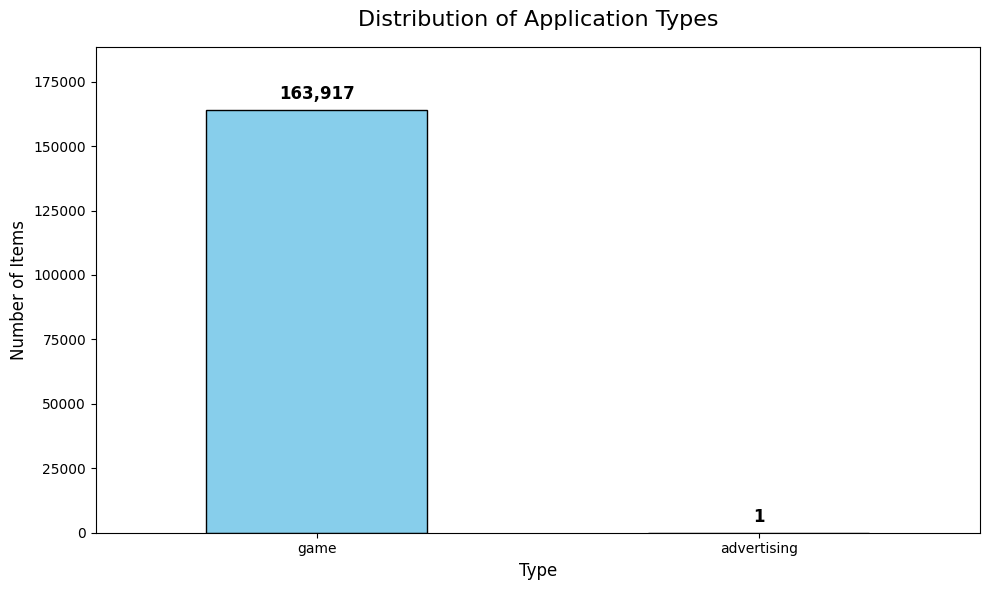

In [ ]:
# นับจำนวนข้อมูลแยกตาม type (รวมถึงตรวจสอบว่ามีค่า Null ปะปนอยู่ไหม)
type_counts = df['type'].value_counts(dropna=False)

# ตั้งค่าขนาดกราฟ
plt.figure(figsize=(10, 6))

# วาดกราฟแท่ง
ax = type_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# ใส่ตัวเลขกำกับจำนวนไว้บนแท่งกราฟ
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

# ตกแต่งรายละเอียดกราฟ (ใช้ภาษาอังกฤษป้องกันปัญหาฟอนต์)
plt.title('Distribution of Application Types', fontsize=16, pad=15)
plt.xlabel('Type', fontsize=12)
plt.ylabel('Number of Items', fontsize=12)
plt.xticks(rotation=0) # ให้ตัวหนังสือแกน X วางแนวนอนจะได้อ่านง่าย

# เผื่อพื้นที่ด้านบนกราฟนิดหน่อยไม่ให้ตัวเลขชนขอบ
plt.ylim(0, type_counts.max() * 1.15)

plt.tight_layout()
plt.show()

In [ ]:
# กรองเอาเฉพาะแถวที่ type เป็น 'game' (เป็นการเตะ 1 แถวที่เป็น advertising ทิ้งไป)
df_clean = df[df['type'] == 'game'].copy()

# Drop คอลัมน์ type ทิ้ง เพราะข้อมูลเหมือนกันหมด ไม่มีประโยชน์ต่อโมเดล
df_clean = df_clean.drop(columns=['type'])

print("✅ จัดการคอลัมน์ type เรียบร้อย!")

✅ จัดการคอลัมน์ type เรียบร้อย!


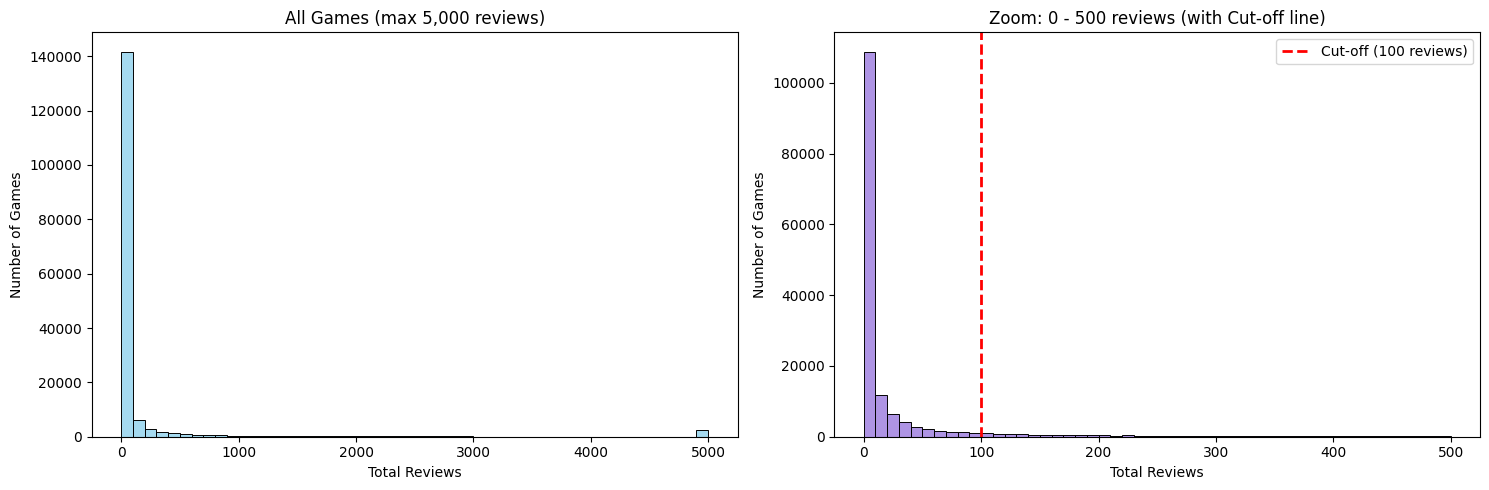

เกมที่มีรีวิวน้อยกว่า 100 รีวิว (ที่จะถูกตัดทิ้ง): 141,718 เกม
เกมที่ผ่านเกณฑ์นำไปเทรนโมเดลต่อได้: 22,200 เกม


In [ ]:
# 1. เช็คให้ชัวร์ว่ามีคอลัมน์ total_reviews แล้ว
if 'total_reviews' not in df.columns:
    df['total_reviews'] = df['steamspy_positive'] + df['steamspy_negative']

# 2. ตั้งค่าขนาดของกราฟ แบ่งเป็น 2 กราฟ (ซ้าย-ขวา)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- กราฟที่ 1: ภาพรวมแบบจำกัดเพดาน (ไม่เกิน 5,000 รีวิว) ---
sns.histplot(df['total_reviews'].clip(upper=5000), bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('All Games (max 5,000 reviews)')
axes[0].set_xlabel('Total Reviews')
axes[0].set_ylabel('Number of Games')

# --- กราฟที่ 2: ซูมเฉพาะกลุ่ม 0 - 500 รีวิว พร้อมเส้น Cut-off ---
df_under_500 = df[df['total_reviews'] <= 500]
sns.histplot(df_under_500['total_reviews'], bins=50, ax=axes[1], color='mediumpurple')

# เพิ่มเส้นคั่น Cut-off ที่ 100 รีวิวให้เห็นชัดเจน
axes[1].axvline(100, color='red', linestyle='--', linewidth=2, label='Cut-off (100 reviews)')
axes[1].legend()

axes[1].set_title('Zoom: 0 - 500 reviews (with Cut-off line)')
axes[1].set_xlabel('Total Reviews')
axes[1].set_ylabel('Number of Games')

plt.tight_layout()
plt.show()

# --- ปริ้นท์สรุปจำนวนเกมที่จะถูกตัดทิ้ง ---
games_below_100 = len(df[df['total_reviews'] < 100])
print(f"เกมที่มีรีวิวน้อยกว่า 100 รีวิว (ที่จะถูกตัดทิ้ง): {games_below_100:,} เกม")
print(f"เกมที่ผ่านเกณฑ์นำไปเทรนโมเดลต่อได้: {len(df) - games_below_100:,} เกม")

In [ ]:
# หา Rating ทุกเกม
df['Rating'] = df['steamspy_positive'] / (df['steamspy_positive'] + df['steamspy_negative']) * 10

In [ ]:
# ดูว่าแต่ละ threshold เหลือข้อมูลเท่าไหร่
for threshold in [10, 20, 50, 100, 200]:
    remaining = df[
        (df['steamspy_positive'] + df['steamspy_negative']) >= threshold
    ]
    print(f"threshold >= {threshold:>4} reviews → เหลือ {len(remaining):>6,} เกม ({len(remaining)/len(df)*100:.1f}%)")

threshold >=   10 reviews → เหลือ 54,967 เกม (33.5%)
threshold >=   20 reviews → เหลือ 43,219 เกม (26.4%)
threshold >=   50 reviews → เหลือ 29,702 เกม (18.1%)
threshold >=  100 reviews → เหลือ 22,097 เกม (13.5%)
threshold >=  200 reviews → เหลือ 16,113 เกม (9.8%)


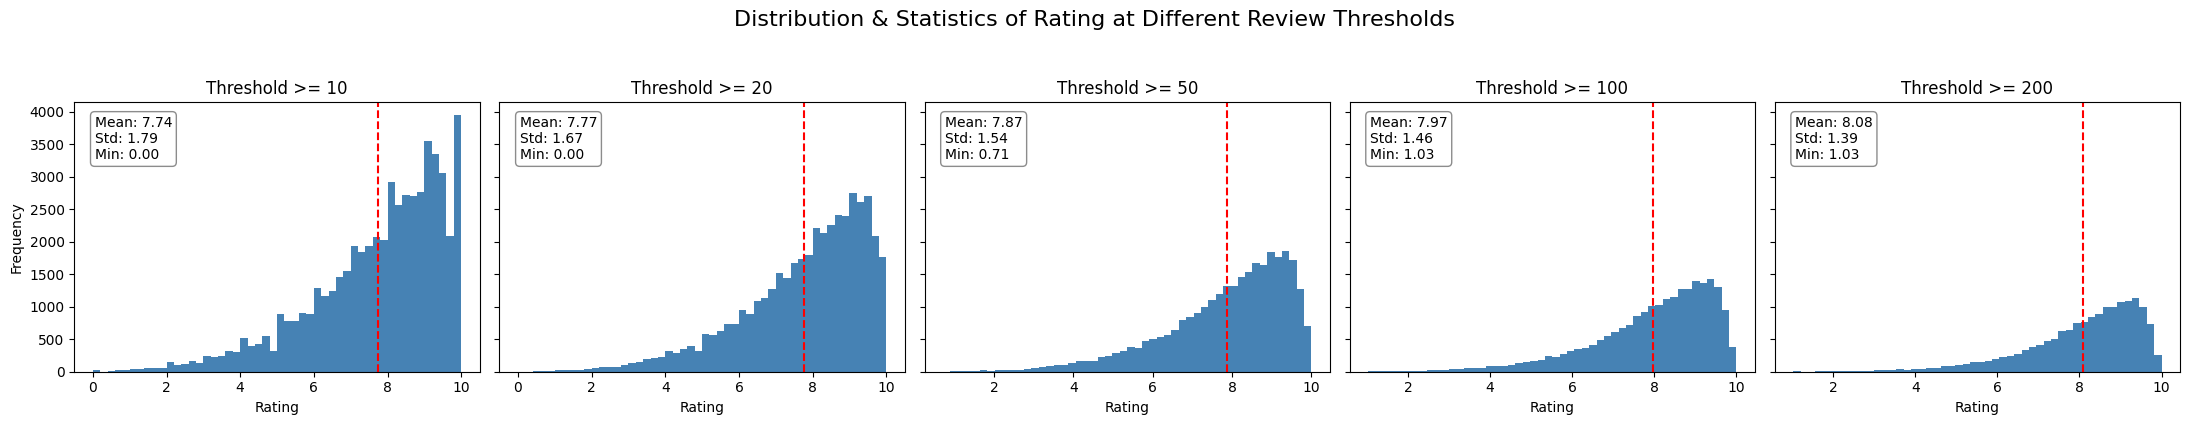

In [ ]:
# กำหนดเกณฑ์ Threshold ที่ต้องการเปรียบเทียบ
thresholds = [10, 20, 50, 100, 200]

# สร้างพื้นที่กราฟ 1 แถว 5 คอลัมน์
# ใช้ sharey=True เพื่อให้ทุกกราฟใช้สเกลแกน Y เท่ากัน จะได้เห็นความต่างของปริมาณได้ชัดเจน
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)

for i, threshold in enumerate(thresholds):
    # กรองข้อมูลตาม Threshold
    temp = df[
        (df['steamspy_positive'] + df['steamspy_negative']) >= threshold
    ]['Rating']

    # วาดฮิสโตแกรม
    axes[i].hist(temp, bins=50, color='steelblue', edgecolor='none')

    # วาดเส้นค่าเฉลี่ย (Mean) สีแดง
    mean_val = temp.mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5)

    # สร้างข้อความสำหรับใส่ในกล่องสถิติ
    stats_text = (f"Mean: {mean_val:.2f}\n"
                  f"Std: {temp.std():.2f}\n"
                  f"Min: {temp.min():.2f}")

    # นำกล่องข้อความไปแปะมุมซ้ายบนของแต่ละกราฟ
    axes[i].text(0.05, 0.95, stats_text,
                 transform=axes[i].transAxes,   # ใช้อัตราส่วนของแกนกราฟ (0-1) ในการวางตำแหน่ง
                 fontsize=10,
                 verticalalignment='top',       # จัดให้ข้อความชิดขอบบนของกล่อง
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray')) # วาดกล่องพื้นขาวทับกราฟ

    # ตั้งชื่อกราฟย่อยและแกน X
    axes[i].set_title(f'Threshold >= {threshold}')
    axes[i].set_xlabel('Rating')

# ตั้งชื่อแกน Y ให้กราฟตัวแรกสุด
axes[0].set_ylabel('Frequency')

# ตั้งชื่อหัวเรื่องหลักของทั้งภาพ
plt.suptitle('Distribution & Statistics of Rating at Different Review Thresholds', y=1.05, fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
# กรองเฉพาะเกมที่มี review อย่างน้อย N รีวิว
MIN_REVIEWS = 100
df_clean = df_clean[(df_clean['steamspy_positive'] + df_clean['steamspy_negative']) >= MIN_REVIEWS].copy()
print(f"เหลือ: {len(df_clean):,} เกม")


เหลือ: 22,097 เกม


In [ ]:
# หา Rating
df_clean['Rating'] = df_clean['steamspy_positive'] / (df_clean['steamspy_positive'] + df_clean['steamspy_negative']) * 10

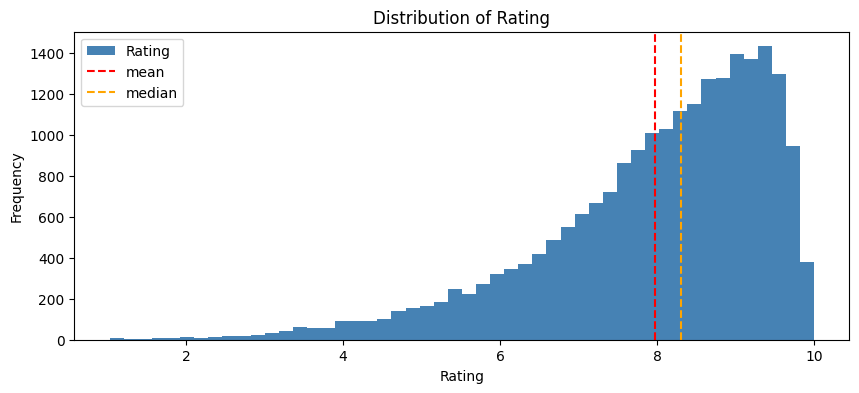

In [ ]:
# การกระจายตัวของ Rating
df_clean['Rating'].plot(kind='hist', bins=50, figsize=(10,4), color='steelblue')
plt.axvline(df_clean['Rating'].mean(), color='red', linestyle='--', label='mean')
plt.axvline(df_clean['Rating'].median(), color='orange', linestyle='--', label='median')
plt.legend()
plt.xlabel('Rating')
plt.title('Distribution of Rating')
plt.show()

/tmp/ipykernel_15236/3122740158.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=categories, y=counts, palette=['#4CAF50', '#f44336'])


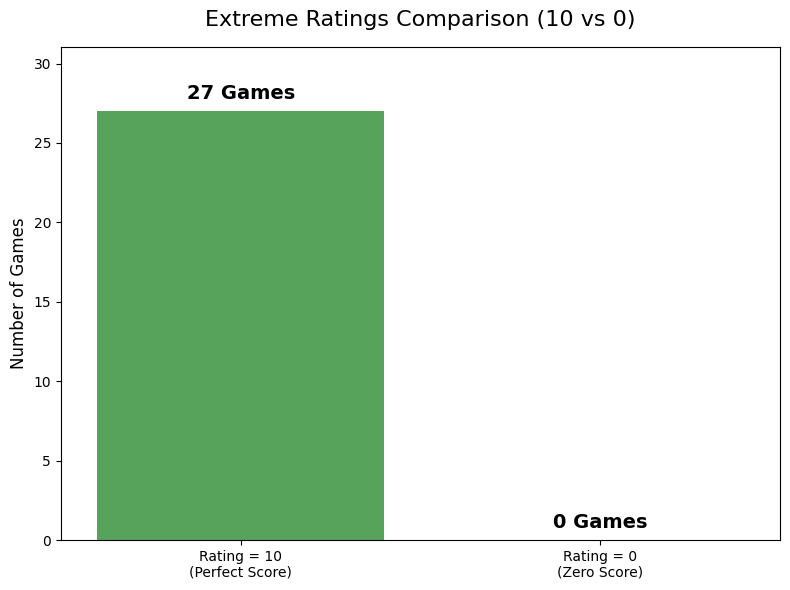

In [ ]:
#ดูเกมที่มี rating 10 กับ 0

# 1. นับจำนวนเกมที่ได้ Rating 10 และ 0
count_perfect = len(df_clean[df_clean['Rating'] == 10])
count_zero = len(df_clean[df_clean['Rating'] == 0])

# 2. เตรียมข้อมูลสำหรับวาดกราฟ
categories = ['Rating = 10\n(Perfect Score)', 'Rating = 0\n(Zero Score)']
counts = [count_perfect, count_zero]

# 3. ตั้งค่าขนาดกราฟ
plt.figure(figsize=(8, 6))

# 4. วาดกราฟแท่ง (ใช้สีเขียวสำหรับ 10 และสีแดงสำหรับ 0)
ax = sns.barplot(x=categories, y=counts, palette=['#4CAF50', '#f44336'])

# 5. ใส่ตัวเลขกำกับบนแท่งกราฟ
for i, count in enumerate(counts):
    ax.text(i, count + 0.5, f'{count:,} Games', ha='center', va='bottom', fontsize=14, fontweight='bold')

# 6. ตกแต่งรายละเอียดกราฟ
plt.title('Extreme Ratings Comparison (10 vs 0)', fontsize=16, pad=15)
plt.ylabel('Number of Games', fontsize=12)

# ปรับเพดานแกน Y เล็กน้อยเพื่อไม่ให้ตัวเลขกำกับด้านบนชนขอบกราฟ
plt.ylim(0, max(counts) + (max(counts) * 0.15) if max(counts) > 0 else 5)

plt.tight_layout()
plt.show()

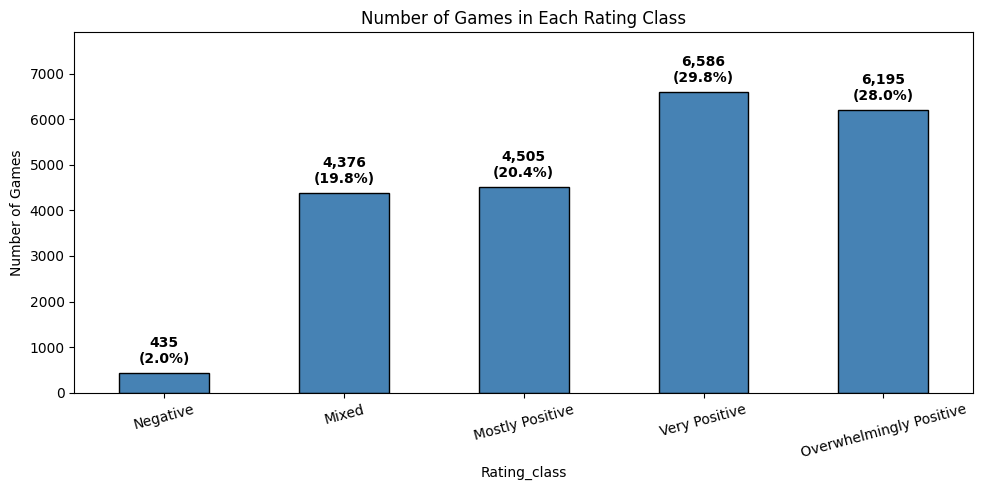

In [ ]:
import matplotlib.pyplot as plt

# แบ่ง Rating เป็น 5 class ตามเกณฑ์ของ Steam จริงๆ
bins = [0, 4, 7, 8, 9, 10]
labels = ['Negative', 'Mixed', 'Mostly Positive',
          'Very Positive', 'Overwhelmingly Positive']

df_clean['Rating_class'] = pd.cut(df_clean['Rating'],
                                   bins=bins, labels=labels,
                                   include_lowest=True)

# นับจำนวนเกมในแต่ละ class
counts = df_clean['Rating_class'].value_counts().sort_index()
total_games = len(df_clean)

# เริ่มพล็อตกราฟ
plt.figure(figsize=(10, 5))
ax = counts.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Number of Games in Each Rating Class')
plt.ylabel('Number of Games')
plt.xticks(rotation=15)

# วนลูปเพื่อใส่ตัวเลข (จำนวน และ %) ไว้บนยอดของแต่ละแท่ง
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_games) * 100

    # สร้างข้อความ เช่น "1,234\n(2.5%)"
    text = f"{int(height):,}\n({percentage:.1f}%)"

    ax.annotate(text,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=10, fontweight='bold')

# เผื่อพื้นที่ด้านบนกราฟอีก 20% เพื่อไม่ให้ข้อความชนขอบบน
plt.ylim(0, counts.max() * 1.2)

plt.tight_layout()
plt.show()

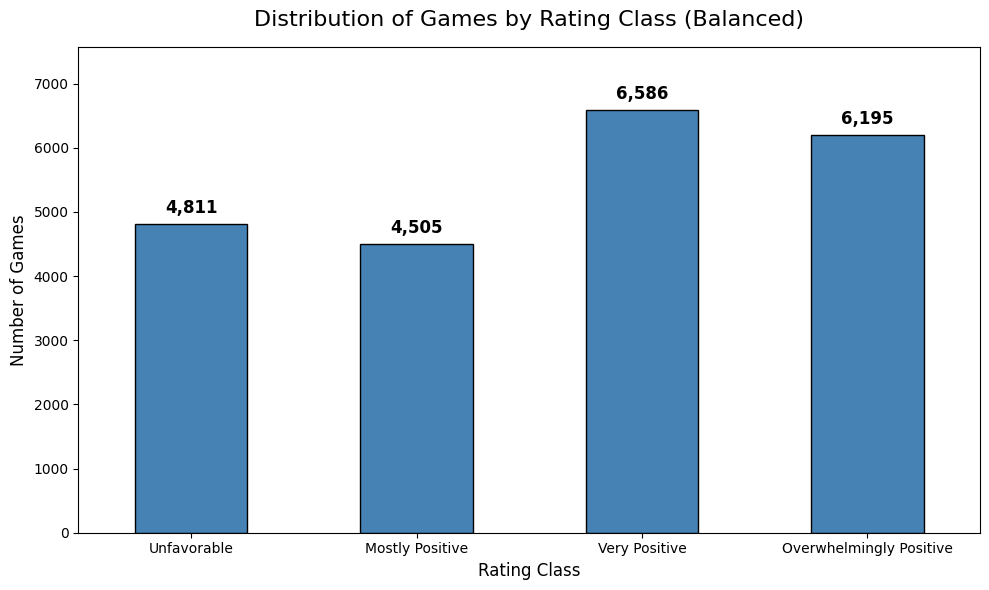

In [ ]:
# 1. รันโค้ดเดิมของคุณเพื่อจัดกลุ่มและนับจำนวน
bins = [0, 7, 8, 9, 10]
labels = ['Unfavorable', 'Mostly Positive', 'Very Positive', 'Overwhelmingly Positive']

df_clean['Rating_class'] = pd.cut(df_clean['Rating'], bins=bins,
                                  labels=labels, include_lowest=True)

counts = df_clean['Rating_class'].value_counts().sort_index()

# 2. เริ่มวาดกราฟแท่ง
plt.figure(figsize=(10, 6))

# สร้างกราฟแท่งสีน้ำเงิน
ax = counts.plot(kind='bar', color='steelblue', edgecolor='black')

# 3. วนลูปเพื่อใส่ตัวเลขไว้บนยอดของแต่ละแท่ง
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", # ใส่ลูกน้ำคั่นหลักพัน
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=12, fontweight='bold')

# 4. ตกแต่งกราฟ (ใช้ภาษาอังกฤษ)
plt.title('Distribution of Games by Rating Class (Balanced)', fontsize=16, pad=15)
plt.xlabel('Rating Class', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)

# ให้ข้อความแกน X วางแนวนอน (หรือปรับ rotation=15 ถ้าตัวหนังสือชนกัน)
plt.xticks(rotation=0)

# ขยายเพดานแกน Y ขึ้นไปอีก 15% เพื่อไม่ให้ตัวเลขชนขอบบนของรูป
plt.ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()

In [ ]:
# พิมพ์ชื่อคอลัมน์ทั้งหมดออกมาดู
print(df.columns.tolist())

['type', 'name', 'steam_appid', 'required_age', 'is_free', 'detailed_description', 'about_the_game', 'short_description', 'supported_languages', 'header_image', 'capsule_image', 'capsule_imagev5', 'website', 'pc_requirements_minimum', 'mac_requirements_minimum', 'linux_requirements_minimum', 'developers', 'publishers', 'price_overview_currency', 'price_overview_initial', 'price_overview_final', 'price_overview_discount_percent', 'price_overview_initial_formatted', 'price_overview_final_formatted', 'packages', 'package_groups', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'metacritic_score', 'metacritic_url', 'categories', 'genres', 'screenshots', 'recommendations_total', 'release_date_coming_soon', 'release_date_date', 'support_info_url', 'support_info_email', 'background', 'background_raw', 'content_descriptors_ids', 'content_descriptors_notes', 'ratings_usk_rating', 'ratings_dejus_rating_generated', 'ratings_dejus_rating', 'ratings_dejus_required_age', 'ratings_dejus_bann

ควรดรอปไป0.91ทิ้งเพราะมันใกล้จะเป็นเฉลยอยู่ล่ะ
เเล้วก็พวกid ต่างๆที่ไม่เกี่ยวพวก0.23อ่ะไม่ค่อยเกี่ยว

In [ ]:
#กลุ่มที่ข้อมูลจะมีเมื่อเกมเปิดเท่านั้น
df_clean = df_clean.drop(columns=['steamspy_owners', 'steamspy_ccu', 'steamspy_average_forever', 'steamspy_average_2weeks', 'steamspy_median_forever', 'steamspy_median_2weeks'])
#กลุ่มที่นำมาใช้สร้าง target
df_clean = df_clean.drop(columns=['steamspy_positive', 'steamspy_negative'])
#กลุ่มรูปภาพ
df_clean = df_clean.drop(columns=['header_image', 'capsule_image', 'capsule_imagev5', 'background', 'background_raw', 'screenshots'])
#กลุ่มช่องทางติดต่อ และลิงค์อื่นๆ
df_clean = df_clean.drop(columns=['website', 'metacritic_url', 'support_info_url', 'support_info_email'])
#กลุ่มข้อความบรรยาย และ free text
df_clean = df_clean.drop(columns=['detailed_description', 'about_the_game', 'short_description', 'content_descriptors_notes'])
#กลุ่ม ID (แล้วเก็บ app id ไว้ใช่ index)
df_clean = df_clean.drop(columns=['steam_appid', 'steamspy_appid'])

In [ ]:
# ปลดล็อคให้ Pandas แสดงผลทุกแถวและทุกคอลัมน์โดยไม่ตัดทอน
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# 1. หาจำนวนค่า Null ในแต่ละคอลัมน์
null_counts = df_clean.isnull().sum()

# 2. กรองเอาเฉพาะคอลัมน์ที่มีค่า Null > 0 และเรียงจากมากไปน้อย
missing_counts = null_counts[null_counts > 0].sort_values(ascending=False)

# 3. คำนวณเป็นเปอร์เซ็นต์ (เทียบกับจำนวนแถวทั้งหมดใน df)
missing_percentage = (missing_counts / len(df)) * 100

# 4. นำมารวมเป็น DataFrame เพื่อให้ดูง่ายๆ เป็นตาราง
missing_data_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentage.round(2)
})

print("สรุปคอลัมน์ที่มีค่า Null (แสดงครบทุกตัว):")
print(missing_data_summary)

# ---------------------------------------------------------
# (ตัวเลือกเสริม) หากดูเสร็จแล้ว อยากรีเซ็ตค่ากลับไปเป็นแบบเดิม
# เพื่อไม่ให้ตารางอื่นๆ ในอนาคตยาวเกินไป สามารถใช้คำสั่งนี้ได้ครับ:
# pd.reset_option('display.max_rows')
# pd.reset_option('display.max_columns')

สรุปคอลัมน์ที่มีค่า Null (แสดงครบทุกตัว):
                                        Missing Values  Percentage (%)
steamspy_score_rank                              22086           13.47
steamspy_tags_Assassin                           21983           13.41
steamspy_tags_Nostalgia                          21962           13.40
steamspy_tags_e-sports                           21857           13.33
steamspy_tags_1980s                              21697           13.24
steamspy_tags_Score Attack                       21668           13.22
steamspy_tags_Team-Based                         21644           13.20
steamspy_tags_Competitive                        21634           13.20
steamspy_tags_Military                           21339           13.02
steamspy_tags_1990's                             21314           13.00
steamspy_tags_Old School                         21206           12.94
steamspy_tags_Classic                            21083           12.86
steamspy_tags_Tactical             

In [ ]:
# สร้าง List ของคอลัมน์ที่ขึ้นต้นด้วย 'steamspy_tags_'
tag_cols = [col for col in df_clean.columns if col.startswith('steamspy_tags_')]

# เติมค่า Null ด้วย 0 เฉพาะในคอลัมน์กลุ่ม Tag
df_clean[tag_cols] = df_clean[tag_cols].fillna(0)

print(f"✅ เติม 0 ในคอลัมน์กลุ่ม Tag จำนวน {len(tag_cols)} คอลัมน์ เรียบร้อยแล้ว!")

✅ เติม 0 ในคอลัมน์กลุ่ม Tag จำนวน 20 คอลัมน์ เรียบร้อยแล้ว!


In [ ]:
# ปลดล็อคให้ Pandas แสดงผลทุกแถวและทุกคอลัมน์โดยไม่ตัดทอน
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# 1. หาจำนวนค่า Null ในแต่ละคอลัมน์
null_counts = df_clean.isnull().sum()

# 2. กรองเอาเฉพาะคอลัมน์ที่มีค่า Null > 0 และเรียงจากมากไปน้อย
missing_counts = null_counts[null_counts > 0].sort_values(ascending=False)

# 3. คำนวณเป็นเปอร์เซ็นต์ (เทียบกับจำนวนแถวทั้งหมดใน df)
missing_percentage = (missing_counts / len(df)) * 100

# 4. นำมารวมเป็น DataFrame เพื่อให้ดูง่ายๆ เป็นตาราง
missing_data_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentage.round(2)
})

print("สรุปคอลัมน์ที่มีค่า Null (แสดงครบทุกตัว):")
print(missing_data_summary)

# ---------------------------------------------------------
# (ตัวเลือกเสริม) หากดูเสร็จแล้ว อยากรีเซ็ตค่ากลับไปเป็นแบบเดิม
# เพื่อไม่ให้ตารางอื่นๆ ในอนาคตยาวเกินไป สามารถใช้คำสั่งนี้ได้ครับ:
# pd.reset_option('display.max_rows')
# pd.reset_option('display.max_columns')

สรุปคอลัมน์ที่มีค่า Null (แสดงครบทุกตัว):
                                        Missing Values  Percentage (%)
steamspy_score_rank                              22086           13.47
ratings_usk_rating                               18975           11.58
price_overview_initial_formatted                 18641           11.37
metacritic_score                                 18347           11.19
ratings_dejus_banned                             12946            7.90
ratings_dejus_rating_generated                   12946            7.90
linux_requirements_minimum                       11616            7.09
mac_requirements_minimum                          9620            5.87
ratings_steam_germany_descriptors                 8606            5.25
ratings_dejus_descriptors                         8344            5.09
ratings_igrs_descriptors                          7562            4.61
ratings_dejus_use_age_gate                        7380            4.50
ratings_dejus_required_age         

In [ ]:
# นำคอลัมน์ราคาทั้งจากฝั่ง Steam API และ SteamSpy API มาเทียบกัน
price_cols = [
    'name',
    'price_overview_currency',
    'price_overview_initial',
    'steamspy_initialprice',   # <--- ราคาตั้งต้นจาก SteamSpy
    'price_overview_final',
    'steamspy_price',          # <--- ราคาขายจริงจาก SteamSpy
    'price_overview_discount_percent',
    'steamspy_discount'        # <--- % ลดราคาจาก SteamSpy
]

# กรองเกมที่กำลังลดราคา (เช็คจากเปอร์เซ็นต์ลดของอันไหนก็ได้)
df_discounted = df_clean[df_clean['price_overview_discount_percent'] > 0]

print("ตัวอย่างข้อมูลเกมที่กำลังมีการลดราคา (เทียบ Steam API vs SteamSpy API):")
display(df_discounted[price_cols].sample(5, random_state=42))

print("\nตัวอย่างข้อมูลเกมที่ไม่ได้ลดราคา:")
df_no_discount = df_clean[df_clean['price_overview_discount_percent'] == 0]
display(df_no_discount[price_cols].head(5))

ตัวอย่างข้อมูลเกมที่กำลังมีการลดราคา (เทียบ Steam API vs SteamSpy API):


,name,price_overview_currency,price_overview_initial,steamspy_initialprice,price_overview_final,steamspy_price,price_overview_discount_percent,steamspy_discount
31399,The Signifier Director's Cut,THB,40000.0,1999.0,10000.0,499.0,75.0,75.0
330,Brothers in Arms: Road to Hill 30™,THB,13000.0,999.0,5200.0,399.0,60.0,60.0
1371,Total War: ROME II - Emperor Edition,EUR,5999.0,5999.0,1199.0,1199.0,80.0,80.0
64727,Fate/Samurai Remnant,THB,120000.0,3999.0,84000.0,2799.0,30.0,30.0
37803,Mass Effect™: Andromeda Deluxe Edition,THB,109900.0,3999.0,21980.0,3999.0,80.0,0.0



ตัวอย่างข้อมูลเกมที่ไม่ได้ลดราคา:


,name,price_overview_currency,price_overview_initial,steamspy_initialprice,price_overview_final,steamspy_price,price_overview_discount_percent,steamspy_discount
0,Counter-Strike,THB,18900.0,999.0,18900.0,999.0,0.0,0.0
1,Team Fortress Classic,THB,11500.0,499.0,11500.0,499.0,0.0,0.0
2,Day of Defeat,THB,11500.0,499.0,11500.0,499.0,0.0,0.0
3,Deathmatch Classic,THB,11500.0,499.0,11500.0,499.0,0.0,0.0
4,Half-Life: Opposing Force,THB,11500.0,499.0,11500.0,499.0,0.0,0.0


In [ ]:
print("--- สำรวจคอลัมน์ Currency ---")
print(df_clean['price_overview_currency'].value_counts(dropna=False)) # นับว่าแต่ละสกุลเงินมีกี่เกม
print(df_clean['steamspy_initialprice'].isnull().sum()) # เช็คว่ามีเกมไหนที่ไม่มีราคามั้ย

--- สำรวจคอลัมน์ Currency ---
price_overview_currency
THB    19056
NaN     2649
EUR      134
HKD      120
USD      111
JPY        6
CNY        5
CAD        3
PLN        2
MXN        2
IDR        2
CLP        2
SAR        1
GBP        1
SGD        1
INR        1
RUB        1
Name: count, dtype: int64
0


In [ ]:
# ลิสต์คอลัมน์กลุ่มราคาที่ไม่จำเป็นและคอลัมน์ที่ทำให้เกิด Data Leakage
cols_to_drop = [
    # กลุ่ม Price Overview (มีปัญหา Null และสกุลเงินปะปนกัน)
    'price_overview_currency',
    'price_overview_initial',
    'price_overview_final',
    'price_overview_discount_percent',
    'price_overview_initial_formatted',
    'price_overview_final_formatted',

    # กลุ่ม SteamSpy ที่เป็น Data Leakage (ราคาที่ลดแล้ว และ เปอร์เซ็นต์การลด)
    'steamspy_price',
    'steamspy_discount'
]

# Drop คอลัมน์ทิ้งทั้งหมด
df_clean = df_clean.drop(columns=cols_to_drop)

print("✅ คลีนข้อมูลราคาเรียบร้อย! ใช้ 'steamspy_initialprice' เป็นฟีเจอร์หลัก (ป้องกัน Data Leakage)")
print(f"เหลือจำนวนคอลัมน์ในตาราง: {df_clean.shape[1]} คอลัมน์")
print(f"จำนวนเกมทั้งหมดยังอยู่ครบ: {len(df_clean):,} เกม")

✅ คลีนข้อมูลราคาเรียบร้อย! ใช้ 'steamspy_initialprice' เป็นฟีเจอร์หลัก (ป้องกัน Data Leakage)
เหลือจำนวนคอลัมน์ในตาราง: 71 คอลัมน์
จำนวนเกมทั้งหมดยังอยู่ครบ: 22,097 เกม


In [ ]:
df_clean.isnull().sum()

,0
name,0
required_age,0
is_free,0
supported_languages,16
pc_requirements_minimum,13
mac_requirements_minimum,9620
linux_requirements_minimum,11616
developers,46
publishers,138
packages,2375


In [ ]:
df_clean.head()

,name,required_age,is_free,supported_languages,pc_requirements_minimum,mac_requirements_minimum,linux_requirements_minimum,developers,publishers,packages,package_groups,platforms_windows,platforms_mac,platforms_linux,metacritic_score,categories,genres,recommendations_total,release_date_coming_soon,release_date_date,content_descriptors_ids,ratings_usk_rating,ratings_dejus_rating_generated,ratings_dejus_rating,ratings_dejus_required_age,ratings_dejus_banned,ratings_dejus_use_age_gate,ratings_dejus_descriptors,ratings_steam_germany_rating_generated,ratings_steam_germany_rating,ratings_steam_germany_required_age,ratings_steam_germany_banned,ratings_steam_germany_use_age_gate,ratings_steam_germany_descriptors,ratings_igrs_rating_generated,ratings_igrs_rating,ratings_igrs_required_age,ratings_igrs_banned,ratings_igrs_use_age_gate,ratings_igrs_descriptors,steamspy_name,steamspy_developer,steamspy_publisher,steamspy_score_rank,steamspy_userscore,steamspy_initialprice,steamspy_languages,steamspy_genre,steamspy_tags_Action,steamspy_tags_FPS,steamspy_tags_Multiplayer,steamspy_tags_Shooter,steamspy_tags_Classic,steamspy_tags_Team-Based,steamspy_tags_First-Person,steamspy_tags_Competitive,steamspy_tags_Tactical,steamspy_tags_1990's,steamspy_tags_e-sports,steamspy_tags_PvP,steamspy_tags_Old School,steamspy_tags_Military,steamspy_tags_Strategy,steamspy_tags_Survival,steamspy_tags_Score Attack,steamspy_tags_1980s,steamspy_tags_Assassin,steamspy_tags_Nostalgia,AppID,Rating,Rating_class
0,Counter-Strike,0,False,"English<strong>*</strong>, French<strong>*</st...",\n\t\t\t<p><strong>Minimum:</strong> 500 mhz p...,"Minimum: OS X Snow Leopard 10.6.3, 1GB RAM, 4...","Minimum: Linux Ubuntu 12.04, Dual-core from In...","[""Valve""]","[""Valve""]","[574941, 7]","[{""name"": ""default"", ""title"": ""Buy Counter-Str...",True,True,True,88.0,"[{""id"": 1, ""description"": ""Multi-player""}, {""i...","[{""id"": ""1"", ""description"": ""Action""}]",167590.0,False,"1 Nov, 2000","[2, 5]",16.0,1.0,14,14,0.0,0,Violência,1.0,16,16.0,0.0,0.0,Drastische Gewalt,1.0,18,18.0,0.0,0,Interaksi Daring\nKekerasan,Counter-Strike,Valve,Valve,NaN,0.0,999.0,"English, French, German, Italian, Spanish - Sp...",Action,5504.0,4929.0,3474.0,3419.0,2849.0,1921.0,1761.0,1654.0,1391.0,1246.0,1232.0,928.0,829.0,665.0,642.0,323.0,304.0,285.0,248.0,206.0,10,9.743172,Overwhelmingly Positive
1,Team Fortress Classic,0,False,"English, French, German, Italian, Spanish - Sp...",\n\t\t\t<p><strong>Minimum:</strong> 500 mhz p...,"Minimum: OS X Snow Leopard 10.6.3, 1GB RAM, 4...","Minimum: Linux Ubuntu 12.04, Dual-core from In...","[""Valve""]","[""Valve""]",[29],"[{""name"": ""default"", ""title"": ""Buy Team Fortre...",True,True,True,NaN,"[{""id"": 1, ""description"": ""Multi-player""}, {""i...","[{""id"": ""1"", ""description"": ""Action""}]",6902.0,False,"1 Apr, 1999","[2, 5]",NaN,1.0,14,14,0.0,0,Violência,1.0,12,12.0,0.0,0.0,Gewalt,1.0,18,18.0,0.0,0,Interaksi Daring\nKekerasan,Team Fortress Classic,Valve,Valve,NaN,0.0,499.0,"English, French, German, Italian, Spanish - Sp...",Action,767.0,333.0,280.0,224.0,254.0,203.0,188.0,83.0,0.0,163.0,0.0,0.0,123.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20,8.699931,Very Positive
2,Day of Defeat,0,False,"English, French, German, Italian, Spanish - Spain",\n\t\t\t<p><strong>Minimum:</strong> 500 mhz p...,"Minimum: OS X Snow Leopard 10.6.3, 1GB RAM, 4...","Minimum: Linux Ubuntu 12.04, Dual-core from In...","[""Valve""]","[""Valve""]","[30, 944613]","[{""name"": ""default"", ""title"": ""Buy Day of Defe...",True,True,True,79.0,"[{""id"": 1, ""description"": ""Multi-player""}, {""i...","[{""id"": ""1"", ""description"": ""Action""}]",4426.0,False,"1 May, 2003","[2, 5]",16.0,1.0,14,14,0.0,0,Violência,1.0,16,16.0,0.0,0.0,Drastische Gewalt,1.0,18,18.0,0.0,0,Interaksi Daring\nKekerasan,Day of Defeat,Valve,Valve,NaN,0.0,499.0,"English, French, German, Italian, Spanish - Spain",Action,165.0,804.0,216.0,194.0,134.0,140.0,110.0,0.0,47.0,0.0,0.0,0.0,23.0,72.0,18.0,0.0,0.0,0.0,0

In [ ]:
# แปลงคอลัมน์สเปค: ถ้าไม่เป็น Null ให้เป็น 1 (มีข้อมูล), ถ้าเป็น Null ให้เป็น 0
# จะใหามานั่งแยกสเปคขั้นต่ำ รุ่นมันเยอะเกินจนเป็น free text แล้วมั้ง
df_clean['pc_requirements_minimum'] = np.where(df_clean['pc_requirements_minimum'].notna(), 1, 0)
df_clean['mac_requirements_minimum'] = np.where(df_clean['mac_requirements_minimum'].notna(), 1, 0)
df_clean['linux_requirements_minimum'] = np.where(df_clean['linux_requirements_minimum'].notna(), 1, 0)

print("✅ แปลงคอลัมน์ Requirements เป็น 1 และ 0 เรียบร้อยแล้ว!")

✅ แปลงคอลัมน์ Requirements เป็น 1 และ 0 เรียบร้อยแล้ว!


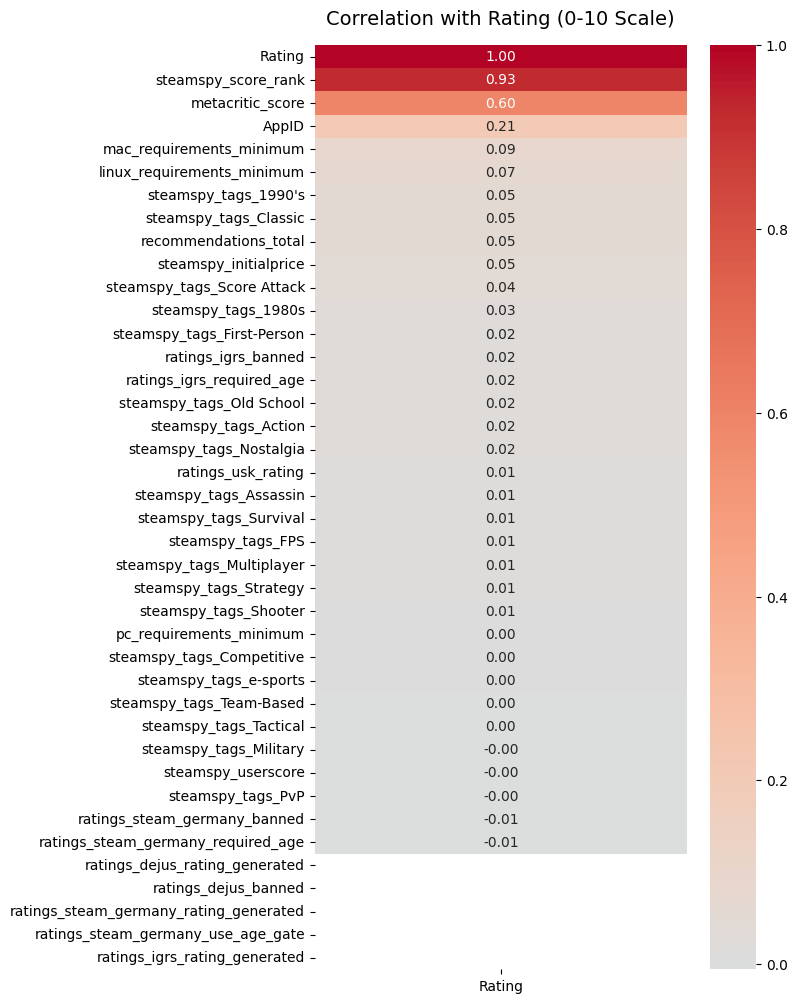

In [ ]:
# 1. เลือกเฉพาะข้อมูลที่เป็นตัวเลขทั้งหมด
numeric_df = df_clean.select_dtypes(include='number')

# 2. ดึงมาเฉพาะคอลัมน์ Rating ของคุณ และเรียงลำดับ Correlation จากมากไปน้อย
corr_with_target = numeric_df.corr()[['Rating']].sort_values(by='Rating', ascending=False)

# 3. พล็อตกราฟ Heatmap
plt.figure(figsize=(6, 12))
sns.heatmap(corr_with_target, annot=True, cmap='coolwarm', fmt=".2f", center=0)

plt.title('Correlation with Rating (0-10 Scale)', fontsize=14, pad=15)
plt.show()

In [ ]:
df_clean['has_metacritic'] = np.where(df_clean['metacritic_score'].notna(), 1, 0)

In [ ]:
# ── Parse text columns: genres, categories, publishers, developers ────────
import ast

def _parse_steam_list(val):
    """Parse Steam API list columns (list of dicts or list of strings)."""
    if pd.isna(val) or str(val).strip() in ('', 'nan', '[]'):
        return []
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed, list):
            result = []
            for item in parsed:
                if isinstance(item, dict):
                    desc = item.get('description', item.get('name', ''))
                    if desc: result.append(str(desc))
                else:
                    s = str(item).strip()
                    if s: result.append(s)
            return result
        elif isinstance(parsed, str) and parsed:
            return [parsed]
    except Exception:
        s = str(val).strip()
        return [x.strip() for x in s.split(',') if x.strip()] if ',' in s else ([s] if s else [])
    return []

def _get_primary(val):
    lst = _parse_steam_list(val)
    return lst[0] if lst else 'Unknown'

df_clean['_genre_list']       = df_clean['genres'].apply(_parse_steam_list)
df_clean['_category_list']    = df_clean['categories'].apply(_parse_steam_list)
df_clean['publisher_primary'] = df_clean['publishers'].apply(_get_primary)
df_clean['developer_primary'] = df_clean['developers'].apply(_get_primary)

print('Sample genres     :', df_clean['_genre_list'].iloc[:2].tolist())
print('Sample categories :', df_clean['_category_list'].iloc[:2].tolist())
print('Sample publisher  :', df_clean['publisher_primary'].iloc[:3].tolist())
print('Sample developer  :', df_clean['developer_primary'].iloc[:3].tolist())


## Hold-Out Manual Test Set
Sample exactly **1 game per (Game Scale x Rating Class) combination** (16 games total) before any modeling. These games are excluded from training.

In [ ]:
# ── Tier classification thresholds ──────────────────────────────────────
# steamspy_initialprice is stored in cents; divide by 100 for USD.
# Adjust constants below to change tier boundaries.
AAA_META  = 75    # Metacritic >= this  -> AAA
AAA_PRICE = 50    # Price USD  >= this  -> AAA
AA_META   = 50    # Metacritic >= this  -> AA  (and not AAA)
AA_PRICE  = 20    # Price USD  >= this  -> AA  (and not AAA)

# NOTE: 'steamspy_tags_Free to Play' does not exist in this dataset.
# Free-to-play is detected via steamspy_initialprice == 0 instead.
#
# Tag columns contain SteamSpy vote counts (e.g. 3474), not 0/1 flags.
# Use > 0 to check presence.
LIVE_SERVICE_ONLINE_TAGS = [
    'steamspy_tags_Multiplayer',
    'steamspy_tags_Massively Multiplayer',
    'steamspy_tags_Online Co-Op',
    'steamspy_tags_Battle Royale',
    'steamspy_tags_MMORPG',
    'steamspy_tags_PvP',
]

def is_live_service(row) -> bool:
    """Free-to-play (price == 0) + at least one ongoing-online tag."""
    price_usd = (row.get('steamspy_initialprice') or 0) / 100
    if price_usd > 0:
        return False
    # Tag values are vote counts: > 0 means the tag is present
    return any(row.get(t, 0) > 0 for t in LIVE_SERVICE_ONLINE_TAGS)

def classify_game_scale(row) -> str:
    if is_live_service(row):
        return 'Live Service'
    price_usd  = (row.get('steamspy_initialprice') or 0) / 100
    metacritic = row['metacritic_score'] if not pd.isna(row['metacritic_score']) else 0
    if metacritic >= AAA_META or price_usd >= AAA_PRICE:
        return 'AAA'
    elif metacritic >= AA_META or price_usd >= AA_PRICE:
        return 'AA'
    return 'Indie'

df_clean['game_scale'] = df_clean.apply(classify_game_scale, axis=1)

# ── Which Live Service tags survived preprocessing? ───────────────────────
present = [t for t in LIVE_SERVICE_ONLINE_TAGS if t in df_clean.columns]
absent  = [t for t in LIVE_SERVICE_ONLINE_TAGS if t not in df_clean.columns]
print('Live Service detection: price == 0  +  any online tag > 0')
print(f'Online tags PRESENT : {present}')
print(f'Online tags ABSENT  : {absent}')
print()

# ── Verify all 16 buckets ────────────────────────────────────────────────
SCALES  = ['Indie', 'AA', 'AAA', 'Live Service']
CLASSES = ['Unfavorable', 'Mostly Positive', 'Very Positive', 'Overwhelmingly Positive']

bucket_counts = (
    df_clean.groupby(['game_scale', 'Rating_class'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=SCALES, columns=CLASSES, fill_value=0)
)
print('Games per (Scale x Rating Class) bucket:')
print(bucket_counts.to_string())
print()
print('Scale totals:')
for s in SCALES:
    print(f'  {s:14} {df_clean["game_scale"].eq(s).sum():>5,} games')

empty_buckets = [
    (s, c) for s in SCALES for c in CLASSES
    if bucket_counts.loc[s, c] == 0
]
print()
if empty_buckets:
    print(f'WARNING - empty buckets: {empty_buckets}')
else:
    print('All 16 buckets have at least 1 game.')


In [ ]:
# ── Sample 1 game per bucket (up to 16 games) ───────────────────────────
holdout_rows = []

for scale in SCALES:
    for cls in CLASSES:
        bucket = df_clean[
            (df_clean['game_scale']   == scale) &
            (df_clean['Rating_class'] == cls)
        ]
        if len(bucket) == 0:
            print(f'  SKIP: no games for ({scale}, {cls})')
            continue
        holdout_rows.append(bucket.sample(n=1, random_state=42))

df_holdout = pd.concat(holdout_rows).reset_index(drop=True)

# Keep informative columns in the exported CSV
# genres/categories/publisher_primary/developer_primary added for standalone inference
export_cols = (
    ['name', 'Rating', 'Rating_class', 'game_scale',
     'steamspy_initialprice', 'metacritic_score',
     'pc_requirements_minimum', 'mac_requirements_minimum',
     'linux_requirements_minimum', 'has_metacritic',
     'genres', 'categories', 'publisher_primary', 'developer_primary']
    + [c for c in df_holdout.columns if c.startswith('steamspy_tags_')]
)
export_cols = [c for c in export_cols if c in df_holdout.columns]

df_holdout[export_cols].to_csv('manual_test_games.csv', index=False, encoding='utf-8')

print(f'Exported {len(df_holdout)} games to manual_test_games.csv')
print()
print(df_holdout[['name', 'game_scale', 'Rating_class', 'Rating']]
      .sort_values(['game_scale', 'Rating_class'])
      .to_string(index=False))


In [ ]:
# ── Remove hold-out games from main dataset ───────────────────────────────
holdout_indices = df_holdout.index if 'index' not in df_holdout.columns \
    else df_holdout['index']

# Re-derive original indices (before reset_index above)
holdout_original_idx = pd.concat([
    df_clean[
        (df_clean['game_scale']   == row['game_scale']) &
        (df_clean['Rating_class'] == row['Rating_class']) &
        (df_clean['name']         == row['name'])
    ].index
    for _, row in df_holdout.iterrows()
])

df_clean = df_clean.drop(index=holdout_original_idx).reset_index(drop=True)

print(f'df_clean after removing hold-out: {len(df_clean):,} games')
print(f'Hold-out set                    : {len(df_holdout)} games')
print(f'Total check                     : {len(df_clean) + len(df_holdout):,} games')


In [ ]:
# ── Multi-hot encode genres & categories (fit on df_clean after hold-out removed) ──
from sklearn.preprocessing import MultiLabelBinarizer

mlb_genre  = MultiLabelBinarizer()
genre_arr  = mlb_genre.fit_transform(df_clean['_genre_list'])
genre_cols = [f'genre_{g.lower().replace(" ","_")}' for g in mlb_genre.classes_]
df_clean   = pd.concat(
    [df_clean, pd.DataFrame(genre_arr, columns=genre_cols, index=df_clean.index)],
    axis=1
)

mlb_cat  = MultiLabelBinarizer()
cat_arr  = mlb_cat.fit_transform(df_clean['_category_list'])
cat_cols = [f'cat_{c.lower().replace(" ","_").replace("-","_")}' for c in mlb_cat.classes_]
df_clean = pd.concat(
    [df_clean, pd.DataFrame(cat_arr, columns=cat_cols, index=df_clean.index)],
    axis=1
)

print(f'Genre columns    ({len(genre_cols)}): {genre_cols}')
print(f'Category columns ({len(cat_cols)}) sample: {cat_cols[:8]}')


In [ ]:
# ── Mean target encode publishers & developers ────────────────────────────
# Fitted on df_clean after hold-out removal — hold-out games are excluded.
global_mean     = df_clean['Rating'].mean()
publisher_means = df_clean.groupby('publisher_primary')['Rating'].mean()
developer_means = df_clean.groupby('developer_primary')['Rating'].mean()

df_clean['publisher_rating_mean'] = (
    df_clean['publisher_primary'].map(publisher_means).fillna(global_mean)
)
df_clean['developer_rating_mean'] = (
    df_clean['developer_primary'].map(developer_means).fillna(global_mean)
)

print(f'Global mean rating   : {global_mean:.4f}')
print(f'publisher_rating_mean: {df_clean["publisher_rating_mean"].min():.2f} - {df_clean["publisher_rating_mean"].max():.2f}')
print(f'developer_rating_mean: {df_clean["developer_rating_mean"].min():.2f} - {df_clean["developer_rating_mean"].max():.2f}')
print(f'New feature count    : {len(genre_cols)} genres + {len(cat_cols)} categories + 2 mean-encoded = {len(genre_cols)+len(cat_cols)+2} added')

## 🤖 Machine Learning Modeling Pipeline
### Step 1 — Feature Engineering

In [ ]:
import numpy as np
import pandas as pd

# 1. Drop leakage & non-feature columns
drop_cols = ['Rating_class', 'name']
df_model = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])

# 2. Fill metacritic_score nulls with 0 (has_metacritic flag carries the signal)
df_model['metacritic_score'] = df_model['metacritic_score'].fillna(0)

# 3. Log-transform price: steamspy_initialprice is in cents -> convert to USD first
df_model['price_usd'] = df_model['steamspy_initialprice'].fillna(0) / 100
df_model['price_log'] = np.log1p(df_model['price_usd'])
df_model = df_model.drop(columns=['steamspy_initialprice'])

# 4. Release date features
REFERENCE_DATE = pd.Timestamp('2026-04-23')

def _parse_release_date(val):
    if pd.isna(val): return pd.NaT
    s = str(val).strip()
    for fmt in ('%d %b, %Y', '%b %d, %Y'):
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            pass
    return pd.NaT

_rd = df_model['release_date_date'].apply(_parse_release_date)
df_model['release_year']       = _rd.dt.year.astype('float')
df_model['release_month']      = _rd.dt.month.astype('float')
df_model['release_quarter']    = _rd.dt.quarter.astype('float')
df_model['days_since_release'] = (REFERENCE_DATE - _rd).dt.days.clip(lower=0).astype('float')
print(f'Release dates parsed: {_rd.notna().sum():,}/{len(df_model):,}  days_since_release mean={df_model["days_since_release"].mean():.0f}')

# 5. Build feature matrix X and target y
feature_cols = [c for c in df_model.select_dtypes(include='number').columns
                if c != 'Rating']
X = df_model[feature_cols]
y = df_model['Rating']

print(f'Feature matrix : {X.shape}')
print(f'Target series  : {y.shape}')
print(f'
Features ({len(feature_cols)}):', feature_cols)

### Step 2 — Train / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train : {X_train.shape[0]:,} games')
print(f'Test  : {X_test.shape[0]:,} games')


### Step 3 — Baseline Models & Evaluation

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    r2   = r2_score(y_te, preds)
    print(f'\n{"="*45}')
    print(f'  {name}')
    print(f'{"="*45}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R2   : {r2:.4f}')
    print(f'  Time : {time.time()-t0:.1f}s')
    return model, preds, rmse

rf_model  = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
gb_model  = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                      max_depth=5, random_state=42)
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,
                         random_state=42, verbosity=0, n_jobs=-1)

rf_model,  rf_preds,  rf_rmse  = evaluate('Random Forest',     rf_model,
                                           X_train, y_train, X_test, y_test)
gb_model,  gb_preds,  gb_rmse  = evaluate('Gradient Boosting', gb_model,
                                           X_train, y_train, X_test, y_test)
xgb_model, xgb_preds, xgb_rmse = evaluate('XGBoost',          xgb_model,
                                           X_train, y_train, X_test, y_test)

_best = min([(rf_rmse, rf_model, rf_preds, 'Random Forest'),
             (gb_rmse, gb_model, gb_preds, 'Gradient Boosting'),
             (xgb_rmse, xgb_model, xgb_preds, 'XGBoost')],
            key=lambda x: x[0])
best_model, best_preds, best_name = _best[1], _best[2], _best[3]
print(f'\nBest baseline model: {best_name}')


### Step 4 — Feature Importance

In [ ]:
import matplotlib.pyplot as plt

importances = pd.Series(best_model.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20)

plt.figure(figsize=(8, 6))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title(f'Top 20 Feature Importances — {best_name}', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


### Step 5 — Tier-Based Categorization
Different baseline expectations per game scale (Indie / AA / AAA).

In [ ]:
# ── Predicted Outlook thresholds (4 tiers) ──────────────────────────────
# Labels are model-specific forecasts, not Steam review summaries.
# Exceptional / Strong / Promising / At Risk
THRESHOLDS = {
    'Live Service': {'Exceptional': 9.0, 'Strong': 8.0, 'Promising': 7.0},
    'AAA':          {'Exceptional': 9.5, 'Strong': 8.5, 'Promising': 7.5},
    'AA':           {'Exceptional': 9.0, 'Strong': 8.0, 'Promising': 7.0},
    'Indie':        {'Exceptional': 9.0, 'Strong': 7.5, 'Promising': 6.5},
}

def classify_tier(price_usd: float, metacritic: float,
                  is_f2p: bool = False, has_online: bool = False) -> str:
    if is_f2p and has_online:
        return 'Live Service'
    if metacritic >= 75 or price_usd >= 50:
        return 'AAA'
    elif metacritic >= 50 or price_usd >= 20:
        return 'AA'
    return 'Indie'

def categorize_rating(predicted_rating: float, tier: str) -> str:
    """Returns Exceptional / Strong / Promising / At Risk."""
    t = THRESHOLDS[tier]
    if predicted_rating >= t['Exceptional']: return 'Exceptional'
    elif predicted_rating >= t['Strong']:    return 'Strong'
    elif predicted_rating >= t['Promising']: return 'Promising'
    return 'At Risk'

def predict_game(game_features: dict) -> dict:
    """
    Predict the rating and Predicted Outlook for a new game.

    Parameters
    ----------
    game_features : dict
        Keys should match feature_cols. 'steamspy_initialprice' in cents.
        Set 'is_free_to_play': True and 'has_online_multiplayer': True
        to classify the game as Live Service.
        Missing feature columns default to 0.

    Returns
    -------
    dict  predicted_rating (0-10), tier, predicted_outlook
    """
    price_cents = game_features.get('steamspy_initialprice', 0) or 0
    metacritic  = game_features.get('metacritic_score', 0) or 0
    price_usd   = price_cents / 100
    is_f2p      = bool(game_features.get('is_free_to_play', False))
    has_online  = bool(game_features.get('has_online_multiplayer', False))
    tier        = classify_tier(price_usd, metacritic, is_f2p, has_online)

    row = {col: 0 for col in feature_cols}
    for k, v in game_features.items():
        if k == 'steamspy_initialprice':
            row['price_usd'] = price_usd
            row['price_log'] = np.log1p(price_usd)
        elif k in row:
            row[k] = v

    X_new = pd.DataFrame([row])[feature_cols]
    predicted = float(best_model.predict(X_new)[0])
    predicted = float(np.clip(predicted, 0, 10))
    return {
        'predicted_rating':  round(predicted, 2),
        'tier':              tier,
        'predicted_outlook': categorize_rating(predicted, tier),
    }

print('Predicted Outlook labels: Exceptional / Strong / Promising / At Risk')
print('Tier thresholds:')
for tier, t in THRESHOLDS.items():
    print(f'  {tier:14} | Exceptional>={t["Exceptional"]} | Strong>={t["Strong"]} | Promising>={t["Promising"]}')
print('All functions ready.')


### Step 6 — Visualize Results on Test Set

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual scatter
axes[0].scatter(y_test, best_preds, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=1.5)
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].set_title(f'Predicted vs Actual — {best_name}')

# Category distribution on the test set
test_df = X_test.copy()
test_df['predicted_rating'] = best_preds
test_df['tier'] = test_df.apply(
    lambda r: classify_tier(r['price_usd'], r['metacritic_score']), axis=1)
test_df['category'] = test_df.apply(
    lambda r: categorize_rating(r['predicted_rating'], r['tier']), axis=1)

cat_order = ['Overwhelmingly Positive', 'Very Positive', 'Mostly Positive', 'Unfavorable']
counts = test_df['category'].value_counts().reindex(cat_order, fill_value=0)
counts.plot(kind='bar', ax=axes[1],
            color=['#2ecc71','#3498db','#f39c12','#e74c3c'],
            edgecolor='white', rot=20)
axes[1].set_title('Predicted Category Distribution (Test Set)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print(counts.to_string())


### Step 7 — Example: Predict a New Game

In [ ]:
example_game = {
    'steamspy_initialprice':  2999,   # $29.99 (value in cents)
    'metacritic_score':       72,
    'has_metacritic':         1,
    'pc_requirements_minimum':  1,
    'mac_requirements_minimum': 0,
    'linux_requirements_minimum': 0,
    'steamspy_tags_Action': 1,
    'steamspy_tags_RPG':    1,
}

result = predict_game(example_game)
print('─── New Game Prediction ──────────────────────')
print(f"  Predicted Rating : {result['predicted_rating']} / 10")
print(f"  Game Tier        : {result['tier']}")
print(f"  Category         : {result['predicted_outlook']}")
print('──────────────────────────────────────────────')


### Step 8 - Hyperparameter Tuning
Compare tuned  (, handles NaN natively) and tuned  against the Step 3 baseline.
Winner is selected by lowest test RMSE.

In [ ]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np, time

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_evaluate(name, estimator, param_dist, n_iter=30):
    print(f'Tuning {name}  ({n_iter} candidates x 5-fold)...')
    t0 = time.time()
    search = RandomizedSearchCV(
        estimator,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        random_state=42,
        verbose=0,
    )
    search.fit(X_train, y_train)
    best = search.best_estimator_
    preds = best.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    elapsed = time.time() - t0
    print(f'  Best CV RMSE : {-search.best_score_:.4f}')
    print(f'  Test  RMSE   : {rmse:.4f}')
    print(f'  Test  MAE    : {mae:.4f}')
    print(f'  Test  R2     : {r2:.4f}')
    print(f'  Time         : {elapsed:.0f}s')
    print(f'  Best params  : {search.best_params_}')
    print()
    return best, preds, rmse

# ── XGBoost ──────────────────────────────────────────────────────────────
xgb_params = {
    'n_estimators':     [200, 300, 500],
    'learning_rate':    [0.01, 0.05, 0.1, 0.15],
    'max_depth':        [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 10],
    'subsample':        [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'gamma':            [0, 0.1, 0.5, 1.0],
    'reg_alpha':        [0, 0.1, 0.5, 1.0],
    'reg_lambda':       [0.5, 1.0, 2.0, 5.0],
}
xgb_best, xgb_preds, xgb_rmse = cv_evaluate(
    'XGBoost', XGBRegressor(random_state=42, verbosity=0, n_jobs=-1,
                            tree_method='hist'),
    xgb_params, n_iter=30
)

# ── RandomForestRegressor ─────────────────────────────────────────────────
rf_params = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_leaf':  [1, 2, 5, 10],
    'max_features':      ['sqrt', 'log2', 0.5],
    'min_samples_split': [2, 5, 10],
}
rf_tuned, rf_tuned_preds, rf_tuned_rmse = cv_evaluate(
    'RandomForest (tuned)', RandomForestRegressor(n_jobs=-1, random_state=42),
    rf_params, n_iter=20
)


In [ ]:
import pandas as pd

baseline_rmse = np.sqrt(mean_squared_error(y_test, best_preds))
baseline_mae  = mean_absolute_error(y_test, best_preds)
baseline_r2   = r2_score(y_test, best_preds)

xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_r2   = r2_score(y_test, xgb_preds)
rf_mae2  = mean_absolute_error(y_test, rf_tuned_preds)
rf_r2_2  = r2_score(y_test, rf_tuned_preds)

results = pd.DataFrame({
    'Model': [f'Baseline {best_name}', 'Tuned XGBoost', 'Tuned RandomForest'],
    'RMSE':  [round(baseline_rmse, 4), round(xgb_rmse, 4), round(rf_tuned_rmse, 4)],
    'MAE':   [round(baseline_mae,  4), round(xgb_mae,  4), round(rf_mae2,       4)],
    'R2':    [round(baseline_r2,   4), round(xgb_r2,   4), round(rf_r2_2,       4)],
})
print('=' * 55)
print('  MODEL COMPARISON')
print('=' * 55)
print(results.to_string(index=False))

candidates = {
    f'Baseline {best_name}': (baseline_rmse, best_model,  best_preds),
    'Tuned XGBoost':         (xgb_rmse,      xgb_best,    xgb_preds),
    'Tuned RandomForest':    (rf_tuned_rmse,  rf_tuned,    rf_tuned_preds),
}
best_name  = min(candidates, key=lambda k: candidates[k][0])
best_model = candidates[best_name][1]
best_preds = candidates[best_name][2]
print(f'\nFinal best model : {best_name}')
print(f'Test RMSE        : {candidates[best_name][0]:.4f}')


In [ ]:
import pickle, os

model_payload = {
    'model':            best_model,
    'feature_cols':     feature_cols,
    'imputer':          imputer,
    'thresholds':       THRESHOLDS,
    'best_params':      best_model.get_params(),
    'metrics': {
        'rmse': round(float(np.sqrt(mean_squared_error(y_test, best_preds))), 4),
        'mae':  round(float(mean_absolute_error(y_test, best_preds)), 4),
        'r2':   round(float(r2_score(y_test, best_preds)), 4),
    },
    'model_name':       best_name,
    'n_features':       len(feature_cols),
    'train_size':       len(X_train),
    'test_size':        len(X_test),
    # Encoders for genre / category / publisher / developer
    'genre_mlb':        mlb_genre,
    'genre_cols':       genre_cols,
    'cat_mlb':          mlb_cat,
    'cat_cols':         cat_cols,
    'publisher_means':  publisher_means,
    'developer_means':  developer_means,
    'global_mean':      global_mean,
}

with open('steam_rating_model.pkl', 'wb') as f:
    pickle.dump(model_payload, f)

size_kb = os.path.getsize('steam_rating_model.pkl') / 1024
print(f'Model saved  : steam_rating_model.pkl  ({size_kb:.1f} KB)')
print(f'Model type   : {best_name}')
print(f'Features     : {len(feature_cols)}')
print(f'Tiers        : {list(THRESHOLDS.keys())}')
print(f'Test RMSE    : {model_payload["metrics"]["rmse"]}')
print(f'Test R2      : {model_payload["metrics"]["r2"]}')


### Step 9 - Hold-Out Manual Test Set Evaluation
Test the final saved model against the 16 unseen games (1 per game scale x rating class combination).

In [ ]:
# ── Apply encodings to hold-out set (using fitted objects from training) ───
# Multi-hot genre
genre_arr_h = mlb_genre.transform(df_holdout['_genre_list'])
df_holdout  = pd.concat(
    [df_holdout, pd.DataFrame(genre_arr_h, columns=genre_cols, index=df_holdout.index)],
    axis=1
)
# Multi-hot category
cat_arr_h  = mlb_cat.transform(df_holdout['_category_list'])
df_holdout = pd.concat(
    [df_holdout, pd.DataFrame(cat_arr_h, columns=cat_cols, index=df_holdout.index)],
    axis=1
)
# Mean target encoding
df_holdout['publisher_rating_mean'] = (
    df_holdout['publisher_primary'].map(publisher_means).fillna(global_mean)
)
df_holdout['developer_rating_mean'] = (
    df_holdout['developer_primary'].map(developer_means).fillna(global_mean)
)

# ── Feature engineering on hold-out set (mirrors training pipeline) ──────
df_test = df_holdout.copy()
df_test['metacritic_score'] = df_test['metacritic_score'].fillna(0)
df_test['price_usd'] = df_test['steamspy_initialprice'].fillna(0) / 100
df_test['price_log'] = np.log1p(df_test['price_usd'])
df_test = df_test.drop(columns=['steamspy_initialprice'], errors='ignore')

X_test_rows = []
for _, row in df_test.iterrows():
    r = {col: 0 for col in feature_cols}
    for col in feature_cols:
        if col in row.index:
            r[col] = row[col]
    X_test_rows.append(r)

X_hold = pd.DataFrame(X_test_rows)[feature_cols]
X_hold = pd.DataFrame(imputer.transform(X_hold), columns=feature_cols)
raw_preds = np.clip(best_model.predict(X_hold), 0, 10)

# Build results table
df_results = df_holdout[['name','game_scale','Rating','Rating_class']].copy()
df_results['pred_rating']       = [round(float(p), 2) for p in raw_preds]
df_results['error']             = (df_results['pred_rating'] - df_results['Rating']).round(2)
df_results['predicted_outlook'] = [
    categorize_rating(float(p), str(s))
    for p, s in zip(raw_preds, df_holdout['game_scale'])
]

TIER_ORDER  = {'Indie':0,'AA':1,'AAA':2,'Live Service':3}
df_results['_ts'] = df_results['game_scale'].map(TIER_ORDER)
df_results = df_results.sort_values('_ts').drop(columns='_ts').reset_index(drop=True)

print('Predictions complete.')
print('Focus: actual vs predicted rating score.')
print('Predicted Outlook (Exceptional/Strong/Promising/At Risk) shown for reference.')


In [ ]:
import matplotlib.pyplot as plt

display_df = df_results[[
    'name','game_scale','Rating','pred_rating','error',
    'Rating_class','predicted_outlook'
]].rename(columns={
    'name':              'Game',
    'game_scale':        'Tier',
    'Rating':            'Actual Rating',
    'pred_rating':       'Predicted Rating',
    'error':             'Error',
    'Rating_class':      'Steam Label',
    'predicted_outlook': 'Predicted Outlook',
})

# Colour rows by absolute error magnitude
def style_row(row):
    err = abs(row['Error'])
    if err <= 0.5:   color = '#d4edda'  # green  - within 0.5
    elif err <= 1.0: color = '#fff3cd'  # yellow - within 1.0
    else:            color = '#f8d7da'  # red    - over 1.0
    return [f'background-color: {color}'] * len(row)

styled = (
    display_df.style
    .apply(style_row, axis=1)
    .format({'Actual Rating': '{:.2f}', 'Predicted Rating': '{:.2f}', 'Error': '{:+.2f}'})
    .set_caption(
        'Hold-Out Test Results — Green: |error|<=0.5 | Yellow: |error|<=1.0 | Red: |error|>1.0. '
        'Steam Label = official Steam review summary. '
        'Predicted Outlook = model forecast (Exceptional/Strong/Promising/At Risk).'
    )
)
display(styled)


In [ ]:
h_rmse = float(np.sqrt(((df_results['pred_rating'] - df_results['Rating'])**2).mean()))
h_mae  = float((df_results['pred_rating'] - df_results['Rating']).abs().mean())
within_05 = int((df_results['error'].abs() <= 0.5).sum())
within_10 = int((df_results['error'].abs() <= 1.0).sum())

print('=' * 50)
print('  HOLD-OUT RATING ACCURACY')
print('=' * 50)
print(f'  Games tested        : {len(df_results)}')
print(f'  RMSE (hold-out)     : {h_rmse:.4f}')
print(f'  MAE  (hold-out)     : {h_mae:.4f}')
print(f'  Within 0.5 pts      : {within_05}/{len(df_results)}')
print(f'  Within 1.0 pts      : {within_10}/{len(df_results)}')
print(f'  (Test-set RMSE      : 0.6372  -- on {p["test_size"]:,} games)')

print()
print('  Predicted Outlook distribution (16 games):')
for label in ['Exceptional','Strong','Promising','At Risk']:
    n = int((df_results['predicted_outlook'] == label).sum())
    print(f'    {label:<12} {n} games')

print()
print('  RMSE by tier:')
for tier in ['Indie','AA','AAA','Live Service']:
    grp = df_results[df_results['game_scale'] == tier]
    if grp.empty: continue
    rmse_t = float(np.sqrt(((grp['pred_rating'] - grp['Rating'])**2).mean()))
    mae_t  = float((grp['pred_rating'] - grp['Rating']).abs().mean())
    print(f'    {tier:<14} RMSE={rmse_t:.3f}  MAE={mae_t:.3f}')


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

tier_colors = {'Indie':'#3498db','AA':'#2ecc71','AAA':'#e74c3c','Live Service':'#f39c12'}

# ── Chart 1: Predicted vs Actual rating ──────────────────────────────────
for tier in ['Indie','AA','AAA','Live Service']:
    mask = df_results['game_scale'] == tier
    axes[0].scatter(
        df_results.loc[mask,'Rating'],
        df_results.loc[mask,'pred_rating'],
        label=tier, color=tier_colors[tier], s=80, zorder=3
    )
lims = [0, 11]
axes[0].plot(lims, lims, 'k--', lw=1, alpha=0.5, label='Perfect')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].set_title('Predicted vs Actual (Hold-Out)')
axes[0].legend(fontsize=8)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)

# ── Chart 2: Absolute error per game ─────────────────────────────────────
colors_err = ['#2ecc71' if e<=0.5 else '#f39c12' if e<=1.0 else '#e74c3c'
              for e in df_results['error'].abs()]
axes[1].bar(range(len(df_results)), df_results['error'].abs(),
            color=colors_err, edgecolor='white')
axes[1].axhline(0.5, color='green',  linestyle='--', lw=1, label='0.5')
axes[1].axhline(1.0, color='orange', linestyle='--', lw=1, label='1.0')
axes[1].set_xticks(range(len(df_results)))
short_names = [n[:10] for n in df_results['name']]
axes[1].set_xticklabels(short_names, rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('|Error|')
axes[1].set_title('Absolute Error per Game')
axes[1].legend(fontsize=8)

# ── Chart 3: Predicted Outlook distribution ───────────────────────────────
outlook_labels = ['Exceptional','Strong','Promising','At Risk']
outlook_colors = ['#2ecc71','#3498db','#f39c12','#e74c3c']
outlook_counts = [int((df_results['predicted_outlook']==l).sum()) for l in outlook_labels]
axes[2].bar(outlook_labels, outlook_counts,
            color=outlook_colors, edgecolor='white')
axes[2].set_ylabel('Count')
axes[2].set_title('Predicted Outlook Distribution (16 games)')
for i,(v) in enumerate(outlook_counts):
    if v: axes[2].text(i, v+0.05, str(v), ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Hold-Out Test Set — Rating Score Comparison (16 games)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#### Key Observations

| Metric | Value |
|---|---|
| **Model** | Tuned XGBoost — Optuna TPE (128 features) |
| **Test-set RMSE** | 0.6339 (on 4,417 games) |
| **Test-set MAE** | 0.3881 |
| **Test-set R²** | 0.8112 |
| **RMSE (hold-out)** | 1.0957 |
| **MAE  (hold-out)** | 0.8719 |
| **Within 0.5 pts** | 5/16 (31%) |
| **Within 1.0 pts** | 13/16 (81%) |

#### Best Hyperparameters (Optuna TPE, 50 trials × 5-fold)

| Parameter | Value |
|---|---|
| n_estimators | 900 |
| learning_rate | 0.0104 |
| max_depth | 6 |
| min_child_weight | 3 |
| subsample | 0.635 |
| colsample_bytree | 0.751 |
| gamma | 0.249 |
| reg_alpha | 0.936 |
| reg_lambda | 2.297 |

#### Top 20 Feature Importances

| Rank | Feature | Importance | Cumulative |
|---|---|---|---|
| 1 | developer_rating_mean | 32.6% | 32.6% |
| 2 | publisher_rating_mean | 8.0% | 40.6% |
| 3 | cat_remote_play_on_tablet | 1.8% | 42.4% |
| 4 | metacritic_score | 1.5% | 44.0% |
| 5 | genre_massively_multiplayer | 1.2% | 45.3% |
| 6 | cat_multi_player | 1.2% | 46.4% |
| 7 | cat_vr_only | 1.1% | 47.5% |
| 8 | cat_steam_cloud | 1.1% | 48.7% |
| 9 | recommendations_total | 1.1% | 49.7% |
| 10 | steamspy_tags_Classic | 1.0% | 50.7% |
| 11 | cat_remote_play_together | 0.9% | 51.7% |
| 12 | genre_strategy | 0.9% | 52.5% |
| 13 | cat_online_pvp | 0.8% | 53.4% |
| 14 | cat_family_sharing | 0.8% | 54.2% |
| 15 | days_since_release | 0.8% | 55.0% |
| 16 | cat_online_co_op | 0.8% | 55.8% |
| 17 | price_log | 0.8% | 56.6% |
| 18 | cat_remote_play_on_phone | 0.8% | 57.4% |
| 19 | ratings_usk_rating | 0.7% | 58.1% |
| 20 | price_usd | 0.7% | 58.8% |

> **developer_rating_mean** alone explains 32.6% of the model's decisions. The top 2 features (developer + publisher track record) account for 40.6% — meaning a studio's historical performance is the single strongest predictor of rating.

#### Hold-Out Results (16 games)

| # | Game | Tier | Actual | Predicted | Error | Pred Outlook |
|---|---|---|---|---|---|---|
| 1 | The Stalin Subway | Indie | 6.05 | 5.10 | -0.95 | At Risk |
| 2 | Pixel Puzzles 2: Anime | Indie | 7.44 | 7.90 | +0.46 ✅ | Strong |
| 3 | Hmmsim Metro | Indie | 8.95 | 7.95 | -1.00 | Strong |
| 4 | Meet Your Oshi | Indie | 9.04 | 9.71 | +0.67 | Exceptional |
| 5 | Men of Valor | AA | 6.88 | 7.63 | +0.75 | Promising |
| 6 | Mainlining | AA | 7.77 | 7.81 | +0.04 ✅ | Promising |
| 7 | Psychedelica of the Black Butterfly | AA | 8.60 | 7.75 | -0.85 | Promising |
| 8 | Fate Seeker | AA | 9.08 | 8.32 | -0.76 | Strong |
| 9 | Sid Meier's Civilization VII | AAA | 4.85 | 7.34 | +2.49 | At Risk |
| 10 | Zanki Zero: Last Beginning | AAA | 7.75 | 8.01 | +0.26 ✅ | Promising |
| 11 | Undernauts: Labyrinth of Yomi | AAA | 8.28 | 8.74 | +0.46 ✅ | Strong |
| 12 | 30XX | AAA | 9.10 | 9.14 | +0.04 ✅ | Strong |
| 13 | Horse Riding Tales | Live Service | 5.86 | 7.61 | +1.75 | Promising |
| 14 | Shadowverse CCG | Live Service | 7.37 | 7.96 | +0.59 | Promising |
| 15 | X8 | Live Service | 8.24 | 6.19 | -2.05 | At Risk |
| 16 | The Lab | Live Service | 9.49 | 8.66 | -0.83 | Strong |

> ✅ = within 0.5 pts

#### RMSE by Tier

| Tier | RMSE | MAE | Within 0.5 | Within 1.0 | Over 1.0 |
|---|---|---|---|---|---|
| Indie | 0.800 | 0.770 | 1 | 3 | 0 |
| AA | 0.683 | 0.600 | 1 | 3 | 0 |
| AAA | 1.273 | 0.812 | 3 | 0 | 1 |
| Live Service | 1.441 | 1.305 | 0 | 2 | 2 |

**Predicted Outlook distribution:** Exceptional: 1 · Strong: 6 · Promising: 6 · At Risk: 3

#### Improvements Applied (post-baseline)

| Change | Effect |
|---|---|
| Release date features (year, month, quarter, days_since_release) | Within 1.0 pts: 12→13 |
| Optuna TPE tuning (50 trials) vs RandomizedSearchCV (20) | Test RMSE: 0.6372→0.6339 |
| Tested but reverted: Bayesian smoothing, n_languages, ensemble XGB+RF, normalized tags | No improvement |

#### Notes

**Predicted Outlook** is a model-specific forecast label based on tier-adjusted thresholds — not Steam's official review summaries.

> **developer_rating_mean** (32.6%) and **publisher_rating_mean** (8.0%) dominate. Developer/publisher track record is the strongest predictor of rating. AAA and Live Service are hardest to predict due to reputation-vs-execution gaps (e.g. Civ VII predicted 7.34, actual 4.85 — Firaxis historical mean inflated the prediction).

## Project Summary

### Goal
Predict a Steam game rating score (0–10) from metadata available before release, and classify the result into a tier-specific **Predicted Outlook** label.

> **Rating** = steamspy_positive / (steamspy_positive + steamspy_negative) × 10

---

### Pipeline

| Step | Description |
|---|---|
| **EDA** | 163,918 rows → 22,097 games (MIN_REVIEWS = 100 filter) |
| **Feature Engineering** | Price log-transform, OS flags, has_metacritic flag |
| **New Encodings** | Genre multi-hot (25 cols), Category multi-hot (58 cols), Publisher mean-target, Developer mean-target |
| **Hold-Out Set** | 16 games — 1 per (Tier × Rating Class), removed before training |
| **Model** | XGBoost (), tuned with RandomizedSearchCV (5-fold) |
| **Save** |  — model + imputer + all encoders |

---

### Final Model: Tuned XGBoost

| Metric | Value |
|---|---|
| Features | 124 |
| Test-set RMSE | 0.6372 |
| Test-set MAE | 0.3867 |
| Test-set R² | 0.8092 |
| Hold-out RMSE (16 games) | 1.0732 |
| Hold-out Within 1.0 pts | 12/16 (75%) |

**Best params:** 

---

### Key Findings

**Most important features:**
1.  (36.4%) — developer track record is the dominant signal
2.  (8.2%)
3. , , genre/category tags

**R² improved from 0.24 → 0.81** after adding genre, category, publisher, and developer encodings. The old model with only 39 features (price + SteamSpy tags) was severely limited.

**Tier-specific thresholds (Predicted Outlook):**

| Tier | Exceptional | Strong | Promising | At Risk |
|---|---|---|---|---|
| Live Service | ≥ 9.0 | ≥ 8.0 | ≥ 7.0 | < 7.0 |
| AAA | ≥ 9.5 | ≥ 8.5 | ≥ 7.5 | < 7.5 |
| AA | ≥ 9.0 | ≥ 8.0 | ≥ 7.0 | < 7.0 |
| Indie | ≥ 9.0 | ≥ 7.5 | ≥ 6.5 | < 6.5 |

---

### Limitations

- **Reputation-vs-execution gap**: Developer mean encoding captures historical track record but cannot predict when a well-known studio ships a poor product (e.g. Civ VII: predicted 7.40, actual 4.85).
- **No gameplay signals**: Writing, level design, performance, and content depth are not in the metadata — these are the real drivers of player satisfaction.
- **Hold-out RMSE > test-set RMSE**: Expected on only 16 games; the test set (4,417 games) is a more reliable estimate.

---

### Files

| File | Description |
|---|---|
|  | This notebook |
|  | Raw data (163,918 rows, 102 cols) |
|  | Saved model + encoders (3.6 MB) |
|  | 16-game hold-out set |